# ARK Teams Demo — Agent & Team YAMLs with MLRun Serving

This notebook demonstrates how to deploy **any** ARK YAML (single Agent **or** multi-agent Team)
through the same generic `DeclarativeRunner` + `AgentsAtScaleDeployer` code.

Strategies covered:
1. Single `kind: Agent` (backward-compatible)
2. `kind: Team` — **sequential**
3. `kind: Team` — **round-robin**
4. `kind: Team` — **selector** (supervisor)
5. `kind: Team` — **graph** (custom DAG)

In [1]:
# Install dependencies (pin langchain to 1.0.x — create_agent was removed in 1.1.0)
!pip install git+https://github.com/mlrun/mlrun@agentic-ai-declerative-team-drawing langchain langchain-openai langgraph requests

  Cloning https://github.com/mlrun/mlrun (to revision agentic-ai-declerative-team-drawing) to /tmp/pip-req-build-jcu_rkgg
  Running command git clone --filter=blob:none --quiet https://github.com/mlrun/mlrun /tmp/pip-req-build-jcu_rkgg
  Running command git checkout -b agentic-ai-declerative-team-drawing --track origin/agentic-ai-declerative-team-drawing
  Switched to a new branch 'agentic-ai-declerative-team-drawing'
  Branch 'agentic-ai-declerative-team-drawing' set up to track remote branch 'agentic-ai-declerative-team-drawing' from 'origin'.
  Resolved https://github.com/mlrun/mlrun to commit 1e1761ac22b93458c1576134ee13db76edd42804
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mlrun: filename=mlrun-0.0.0+unstable-py3-none-any.whl size=1400058 sha256=9d97b8a43536ce390100f408574b5490981824410786014d52dadc23bb3f59a5
  Stored in directory: /tmp/pip-ephem-wheel-cache-aut6dsbe/wh

## Setup — Project & Secrets

In [2]:
import mlrun

PROJECT_NAME = "teams-at-scale"
project = mlrun.get_or_create_project(PROJECT_NAME)

> 2026-02-16 11:35:07,622 [warning] Failed resolving version info. Ignoring and using defaults
> 2026-02-16 11:35:10,749 [warning] Server or client version is unstable. Assuming compatible: {"client_version":"0.0.0+unstable","server_version":"1.10.0-rc40"}
> 2026-02-16 11:35:10,802 [info] Project loaded successfully: {"project_name":"teams-at-scale"}


In [3]:
secrets = {
    "OPENAI_BASE_URL": "https://openai.prod.ai-gateway.quantumblack.com/0e84e897-1c6b-441d-b98b-9dfb140bece5/v1",
    "OPENAI_API_KEY": "eyJhbGciOiJSUzI1NiIsInR5cCIgOiAiSldUIiwia2lkIiA6ICJhZXNKN2kxNGNidnVuTU40MTJrOU5yZ2ROeENhTlJudTNPbC1TU08ycFlJIn0.eyJleHAiOjE3NzEyMzUyNTcsImlhdCI6MTc3MTIzMzQ1OCwiYXV0aF90aW1lIjoxNzcxMjMzNDU2LCJqdGkiOiJmZjM5NGVlMC0xOWEwLTRhOGMtOTVjZS1mZmY4MDIxYjgyOTMiLCJpc3MiOiJodHRwczovL2F1dGgubWNraW5zZXkuaWQvYXV0aC9yZWFsbXMvciIsImF1ZCI6ImJjZDIzNzI4LTNkMjctNDQ3Yy1hMGE5LWVhY2FmMzkzYTZmNSIsInN1YiI6ImVkMmY4OTZlLTNkY2QtNDk2ZS1hNjY1LTc0YTkzYmIzZTA4ZCIsInR5cCI6IklEIiwiYXpwIjoiYmNkMjM3MjgtM2QyNy00NDdjLWEwYTktZWFjYWYzOTNhNmY1Iiwic2Vzc2lvbl9zdGF0ZSI6ImYyZDU0MjQzLWNiMDQtNDZhNy1hYTUxLTMwNzdmZTRhNjNhYiIsImF0X2hhc2giOiIwdzJWZlJFSk55NXQyVmdHQWFlaVlnIiwibmFtZSI6IlRvbWVyIFdlaXR6bWFuIiwiZ2l2ZW5fbmFtZSI6IlRvbWVyIiwiZmFtaWx5X25hbWUiOiJXZWl0em1hbiIsInByZWZlcnJlZF91c2VybmFtZSI6IjJkNGNlMDMxNDNiYzNhYzEiLCJlbWFpbCI6IlRvbWVyX1dlaXR6bWFuQGV4dGVybmFsLm1ja2luc2V5LmNvbSIsImFjciI6IjEiLCJzaWQiOiJmMmQ1NDI0My1jYjA0LTQ2YTctYWE1MS0zMDc3ZmU0YTYzYWIiLCJlbWFpbF92ZXJpZmllZCI6dHJ1ZSwiZm1ubyI6IjMzODU5OTA0IiwiZ3JvdXBzIjpbIkFsbCBGaXJtIFVzZXJzIiwiMGU4NGU4OTctMWM2Yi00NDFkLWI5OGItOWRmYjE0MGJlY2U1Il19.p2ZZNgdcAq9oonZryl6Zy7ypKn1VTNKz086PFTMX8CLM52ObcEE1IjMZ6WapjQIC_No4Ye9n0m2d1Vi_zPFpXfQ024WB171HlgfzcAbNsGXafvWq4Ta4PlOdM8Rok1QF93LCMmlqiBxzjwAOE9lxJY06CcT4wTxcyMAkeGUTOjcoeQUBjcpm2mdDLq5IY-LlY-Sw57G-AsO5yFsaN0Kx7Mlv3Vt-dX4AJush6dU31b5uo4o8i9g3k3uQJBL7fq0tPztY3I2u4Loi7-uDIqehgOsIza9uL5Q_ri7ha6DAQOeQusRBzPA-pWGTjMYVOE9e_k6WqyQMjMCx-yOccaMNlw"
}
project.set_secrets(secrets=secrets)

import os
os.environ["OPENAI_BASE_URL"] = secrets["OPENAI_BASE_URL"]
os.environ["OPENAI_API_KEY"] = secrets["OPENAI_API_KEY"]

## Write tools & graph_initializer

In [ ]:
%%writefile tools.py
from urllib.parse import quote

import requests
from langchain_core.tools import tool

import mlrun
import mlrun.serving as mlrun_serving
from mlrun.agentic.sessions import SessionStore

HEADERS = {
    "User-Agent": "MLRunTeamsDemo/1.0",
    "Accept": "application/json",
}


@tool
def get_coordinates(address: str) -> str:
    """Converts a city/address into latitude,longitude."""
    encoded = quote(address)
    url = f"https://nominatim.openstreetmap.org/search?q={encoded}&format=json&limit=1"
    try:
        resp = requests.get(url, headers=HEADERS, timeout=10)
        if resp.status_code == 200 and resp.json():
            d = resp.json()[0]
            return f"{d['lat']},{d['lon']}"
        return f"Could not find coordinates for '{address}'"
    except Exception as e:
        return f"Error: {e}"


@tool
def get_gridpoints(coordinates: str) -> str:
    """Gets the NWS forecast URL for lat,lon coordinates."""
    try:
        resp = requests.get(
            f"https://api.weather.gov/points/{coordinates}",
            headers=HEADERS,
            timeout=10,
        )
        if resp.status_code == 200:
            return resp.json()["properties"]["forecast"]
        return f"Could not get gridpoints. Status: {resp.status_code}"
    except Exception as e:
        return f"Error: {e}"


@tool
def get_forecast(forecast_url: str) -> str:
    """Fetches the weather forecast from an NWS forecast URL."""
    try:
        resp = requests.get(forecast_url, headers=HEADERS, timeout=10)
        if resp.status_code == 200:
            periods = resp.json()["properties"]["periods"]
            return "\n".join(
                f"{p['name']}: {p['detailedForecast']}" for p in periods[:3]
            )
        return f"Could not get forecast. Status: {resp.status_code}"
    except Exception as e:
        return f"Error: {e}"


def graph_initializer(server: mlrun_serving.GraphServer):
    context = server.context
    if getattr(context, "session_store", None) is None:
        project = mlrun.get_or_create_project("teams-at-scale")
        context.session_store = SessionStore(project=project)

---
## 1. Single Agent — Weather Agent

Same as the original demo. One `kind: Agent` YAML, same deployer code.

In [4]:
weather_yaml = '''
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: weather
spec:
  description: Weather forecasting agent
  prompt: |
    You are a helpful weather assistant. Provide current conditions and forecasts.
    Be concise and direct.
  modelRef:
    name: gpt-4
  tools:
    - name: get_coordinates
    - name: get_gridpoints
    - name: get_forecast
'''

with open('weather-agent.yaml', 'w') as f:
    f.write(weather_yaml)

print("Created weather-agent.yaml")

Created weather-agent.yaml


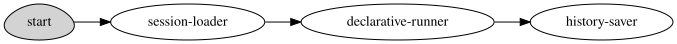

In [4]:
from mlrun.agentic.chains.declarative import AgentsAtScaleDeployer

deployer = AgentsAtScaleDeployer(
    yaml_input="weather-agent.yaml",
    source_file="tools.py",
    project=project,
)
serving_fn = deployer.build(name="single-agent", with_session=True)
serving_fn.spec.graph.plot(rankdir="LR")

In [6]:
deployer.create_mock()
print(deployer.infer("What's the weather in San Francisco?"))

> 2026-02-16 10:02:11,964 [info] DeclarativeRunner initialized: {"kind":"Agent"}
step name:  declarative-runner
step name:  history-saver
In San Francisco, it's currently raining with a temperature around 50°F. The rain is expected to continue through Washington's Birthday with a high near 54°F and temperatures falling to around 52°F in the afternoon. Rain will continue into the evening with a low around 48°F. There's 100% chance of precipitation with significant rainfall amounts expected.


---
## 2. Sequential Team

Three agents execute in order: **researcher** gathers data, **analyst** interprets,
**writer** produces the final report. Each sees the full conversation so far.

In [7]:
sequential_yaml = '''
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: researcher
spec:
  description: Gathers raw weather data for a location
  prompt: |
    You are a weather researcher. Use the tools to gather raw weather data
    for the location the user asks about. Return the raw forecast data.
  modelRef:
    name: gpt-4
  tools:
    - name: get_coordinates
    - name: get_gridpoints
    - name: get_forecast
---
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: analyst
spec:
  description: Analyzes raw weather data and extracts key insights
  prompt: |
    You are a weather analyst. Given raw forecast data from the researcher,
    extract key insights: temperature trends, precipitation probability,
    and any severe weather warnings. Be precise and data-driven.
  modelRef:
    name: gpt-4
---
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: writer
spec:
  description: Writes a polished weather report from analyzed data
  prompt: |
    You are a weather report writer. Given the analyst\'s insights,
    write a concise, friendly weather summary suitable for a morning
    briefing. Use plain language, no jargon.
  modelRef:
    name: gpt-4
---
apiVersion: ark.mckinsey.com/v1alpha1
kind: Team
metadata:
  name: weather-report-team
spec:
  strategy: sequential
  members:
    - name: researcher
      type: agent
    - name: analyst
      type: agent
    - name: writer
      type: agent
'''

with open('sequential-team.yaml', 'w') as f:
    f.write(sequential_yaml)

print("Created sequential-team.yaml")

Created sequential-team.yaml


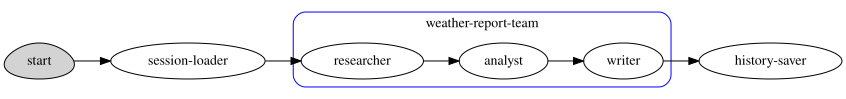

In [8]:
deployer = AgentsAtScaleDeployer(
    yaml_input="sequential-team.yaml",
    source_file="tools.py",
    project=project,
)
serving_fn = deployer.build(name="sequential-team", with_session=True)
serving_fn.spec.graph.plot(rankdir="LR")

In [9]:
deployer.create_mock()
print(deployer.infer("Give me a weather report for New York City"))

step name:  researcher
step name:  analyst
step name:  writer
step name:  history-saver
Good morning everyone!

Expect cooler temperatures today in New York City. We're looking at lows around 32°F and highs around 40°F. And with a chilly wind added into the mix, it might feel as low as 23°F on Monday - just in time for Washington's Birthday. You'll also notice that overnight temperatures are set to rise slightly throughout this period.

As for snow, you'll want to keep those shovels handy. We have a 30% chance of some flurries floating our way overnight on Sunday and before 7 am on Monday, potentially sprinkling less than an inch of new snow. Chances of precipitation drop to 20% on Monday night, but it's uncertain if it'll be snow or rain.

Good news - there are no severe weather warnings on the horizon. Do keep in mind the potential snow and feeling colder than the thermostat might suggest on Monday. This could impact your travel or other plans.

Stay warm, stay safe and have a wonder

---
## 3. Round-Robin Team

Two debating agents take turns refining a travel recommendation.
`maxTurns: 4` means each agent speaks twice, then the team stops.

In [5]:
round_robin_yaml = '''
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: optimist
spec:
  description: Highlights the best aspects of a travel destination
  prompt: |
    You are an enthusiastic travel advisor. Focus on the positives:
    great weather windows, must-see attractions, best seasons to visit.
    Build on prior discussion if any. Keep it to 2-3 sentences.
  modelRef:
    name: gpt-4
---
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: realist
spec:
  description: Adds practical caveats and tips
  prompt: |
    You are a practical travel advisor. Add realistic caveats:
    budget considerations, weather risks, crowd levels, health advisories.
    Build on prior discussion if any. Keep it to 2-3 sentences.
  modelRef:
    name: gpt-4
---
apiVersion: ark.mckinsey.com/v1alpha1
kind: Team
metadata:
  name: travel-debate-team
spec:
  strategy: round-robin
  maxTurns: 4
  members:
    - name: optimist
      type: agent
    - name: realist
      type: agent
'''

with open('roundrobin-team.yaml', 'w') as f:
    f.write(round_robin_yaml)

print("Created roundrobin-team.yaml")

Created roundrobin-team.yaml


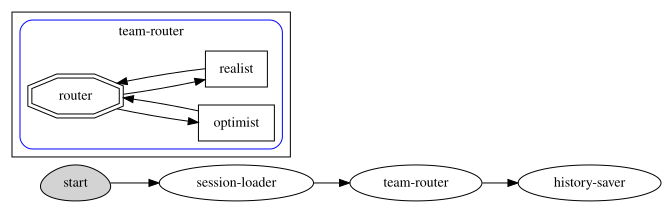

In [6]:
deployer = AgentsAtScaleDeployer(
    yaml_input="roundrobin-team.yaml",
    source_file="tools.py",
    project=project,
)
serving_fn = deployer.build(name="roundrobin-team", with_session=True)
serving_fn.spec.graph.plot(rankdir="LR")

In [7]:
deployer.create_mock()
print(deployer.infer("Should I visit Tokyo in July?"))

> 2026-02-16 11:35:52,609 [info] DeclarativeTeamRouter initialized: {"members":["optimist","realist"],"strategy":"round-robin"}
step name:  history-saver
Tokyo in July can be a great destination due to a bustling festival calendar and summertime energy. However, it's worth noting that it's also a part of the rainy season and can be very humid, which may affect your plans. Also, crowd levels can be high due to summer travel, so pre-booking activities and accommodation is advised.


---
## 4. Selector Team (Supervisor)

A coordinator LLM dynamically picks which specialist to call next based on
the conversation. `selectorPrompt` uses ARK template variables.

In [8]:
selector_yaml = '''
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: coordinator
spec:
  description: Routes queries to the right specialist
  prompt: You are a team coordinator.
  modelRef:
    name: gpt-4
---
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: weather-specialist
spec:
  description: Answers weather-related questions using forecast tools
  prompt: |
    You are a weather specialist. Answer weather questions using your tools.
    Be concise and data-driven.
  modelRef:
    name: gpt-4
  tools:
    - name: get_coordinates
    - name: get_gridpoints
    - name: get_forecast
---
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: travel-specialist
spec:
  description: Provides travel advice, packing tips, and itineraries
  prompt: |
    You are a travel specialist. Provide travel advice including
    packing tips, itinerary suggestions, and local customs.
    Keep answers concise.
  modelRef:
    name: gpt-4
---
apiVersion: ark.mckinsey.com/v1alpha1
kind: Team
metadata:
  name: travel-advisor-team
spec:
  strategy: selector
  maxTurns: 3
  selector:
    agent: coordinator
    selectorPrompt: |
      You are selecting the next team member to respond.
      Available participants: {{.Participants}}
      Their roles:
      {{.Roles}}
      Conversation so far:
      {{.History}}
      Pick the single best participant name for the next turn.
  members:
    - name: weather-specialist
      type: agent
    - name: travel-specialist
      type: agent
'''

with open('selector-team.yaml', 'w') as f:
    f.write(selector_yaml)

print("Created selector-team.yaml")

Created selector-team.yaml


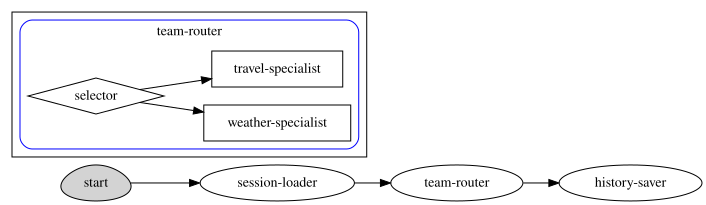

In [9]:
deployer = AgentsAtScaleDeployer(
    yaml_input="selector-team.yaml",
    source_file="tools.py",
    project=project,
)
serving_fn = deployer.build(name="selector-team", with_session=True)
serving_fn.spec.graph.plot(rankdir="LR")

In [10]:
deployer.create_mock()
print(deployer.infer("I'm planning a trip to Chicago next week — what should I pack?"))

> 2026-02-16 11:37:21,065 [info] DeclarativeTeamRouter initialized: {"members":["weather-specialist","travel-specialist"],"strategy":"selector"}
step name:  history-saver
[travel-specialist] As for itinerary suggestions: 
1. Day 1: Discover the Loop - Start at Millennium Park and make sure to see the "Bean" sculpture. After that, walk to Buckingham Fountain and continue to Grant Park. 
2. Day 2: Visit The Magnificent Mile for shopping and dining. In the afternoon, consider visiting Navy Pier.
3. Day 3: Spend the day at Museum Campus, where you'll find the Shedd Aquarium, Field Museum, and Adler Planetarium. 
4. Day 4: Explore neighborhoods like Wicker Park for vintage shopping and Lincoln Park for its free zoo and conservatory. 

As for local customs, Chicagoans are generally friendly and the city is relatively casual. But still maintain a level of formal politeness in interactions. Tipping 15-20% in restaurants and bars is customary.


---
## 5. Graph Team (Custom DAG)

A directed graph where the **researcher** feeds into the **analyst**,
and the analyst feeds into the **writer**. The researcher also has a
direct edge to the writer for simple queries.

```
researcher --> analyst --> writer --> END
    \                       ^
     \---------------------/
```

Since the researcher has two outgoing edges, a selector is used to pick
whether to go through the analyst or skip straight to the writer.

In [11]:
graph_yaml = '''
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: researcher
spec:
  description: Gathers raw weather data
  prompt: |
    You are a weather researcher. Use the tools to gather raw weather
    data for the requested location. Return the raw data.
  modelRef:
    name: gpt-4
  tools:
    - name: get_coordinates
    - name: get_gridpoints
    - name: get_forecast
---
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: analyst
spec:
  description: Deep-dives into weather patterns and anomalies
  prompt: |
    You are a meteorological analyst. Analyze the raw forecast data
    and identify trends, anomalies, and severe weather risks.
    Be technical and precise.
  modelRef:
    name: gpt-4
---
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: writer
spec:
  description: Writes a polished weather summary
  prompt: |
    You are a weather report writer. Produce a concise, friendly
    summary from the data or analysis you received.
    Use plain language.
  modelRef:
    name: gpt-4
---
apiVersion: ark.mckinsey.com/v1alpha1
kind: Agent
metadata:
  name: coordinator
spec:
  description: Routes between analyst and writer
  prompt: You are a team coordinator.
  modelRef:
    name: gpt-4
---
apiVersion: ark.mckinsey.com/v1alpha1
kind: Team
metadata:
  name: weather-graph-team
spec:
  strategy: graph
  maxTurns: 5
  selector:
    agent: coordinator
  members:
    - name: researcher
      type: agent
    - name: analyst
      type: agent
    - name: writer
      type: agent
  graph:
    edges:
      - from: researcher
        to: analyst
      - from: researcher
        to: writer
      - from: analyst
        to: writer
'''

with open('graph-team.yaml', 'w') as f:
    f.write(graph_yaml)

print("Created graph-team.yaml")

Created graph-team.yaml


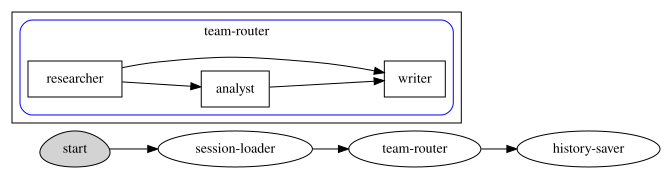

In [12]:
deployer = AgentsAtScaleDeployer(
    yaml_input="graph-team.yaml",
    source_file="tools.py",
    project=project,
)
serving_fn = deployer.build(name="graph-team", with_session=True)
serving_fn.spec.graph.plot(rankdir="LR")

In [13]:
deployer.create_mock()
print(deployer.infer("Give me a detailed weather report for Miami"))

> 2026-02-16 11:37:38,017 [info] DeclarativeTeamRouter initialized: {"members":["researcher","analyst","writer"],"strategy":"graph"}
step name:  history-saver
Greetings to everyone in Miami! Based on the gathered data, expect a beautiful day ahead with plenty of sunshine. The high will be about 81 degrees. The skies will be mostly cloud-free, except for a slight chance of rain showers between 9 am and 10 am. Some gentle breezes will be blowing from the west around 12 mph, making it a perfect day for outdoor activities. 

When night falls, the temperature will drop to around 68 degrees, providing cooler comfort. Skies will turn partly cloudy, but it will remain dry, great for a nighttime stroll.

Tomorrow, keep your sunglasses handy as the sun continues to shine. The temperature will hit a high near 76, with gentle northeast winds blowing at 8 to 12 mph. Overall, it's going to be another fantastic day! Stay hydrated and enjoy the great weather, Miami!


---
## Key Takeaway

Every example above uses **exactly the same deployer code**:

```python
deployer = AgentsAtScaleDeployer(
    yaml_input="<any-ark-yaml>",  # Agent, Team, directory, multi-doc
    source_file="tools.py",
    project=project,
)
deployer.build(name="...", with_session=True)
deployer.create_mock()
deployer.infer("...")
```

The deployer automatically detects the YAML `kind` and `strategy`:

- **Single Agent** — flat `DeclarativeRunner` step (as before)
- **Sequential Team** — linear chain of DeclarativeAgent steps (no router!)
- **Complex Teams** — `DeclarativeTeamRouter` with LangGraph for orchestration

## Architecture by Strategy

### Sequential Team (Simple Linear Flow)
```
SessionLoader → researcher → analyst → writer → HistorySaver
```
- Each agent is a **real serving step**
- No router, no LangGraph
- Output of agent N becomes input of agent N+1

### Complex Teams (Round-Robin/Selector/Graph)
```
SessionLoader → team-router ─┬─ optimist
                             └─ realist
              → HistorySaver
```
- Router with LangGraph handles complex orchestration
- Agents can talk back and forth
- State management for conversation history

No code changes needed when switching between strategies!